In [8]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Plot successfully generated and saved.


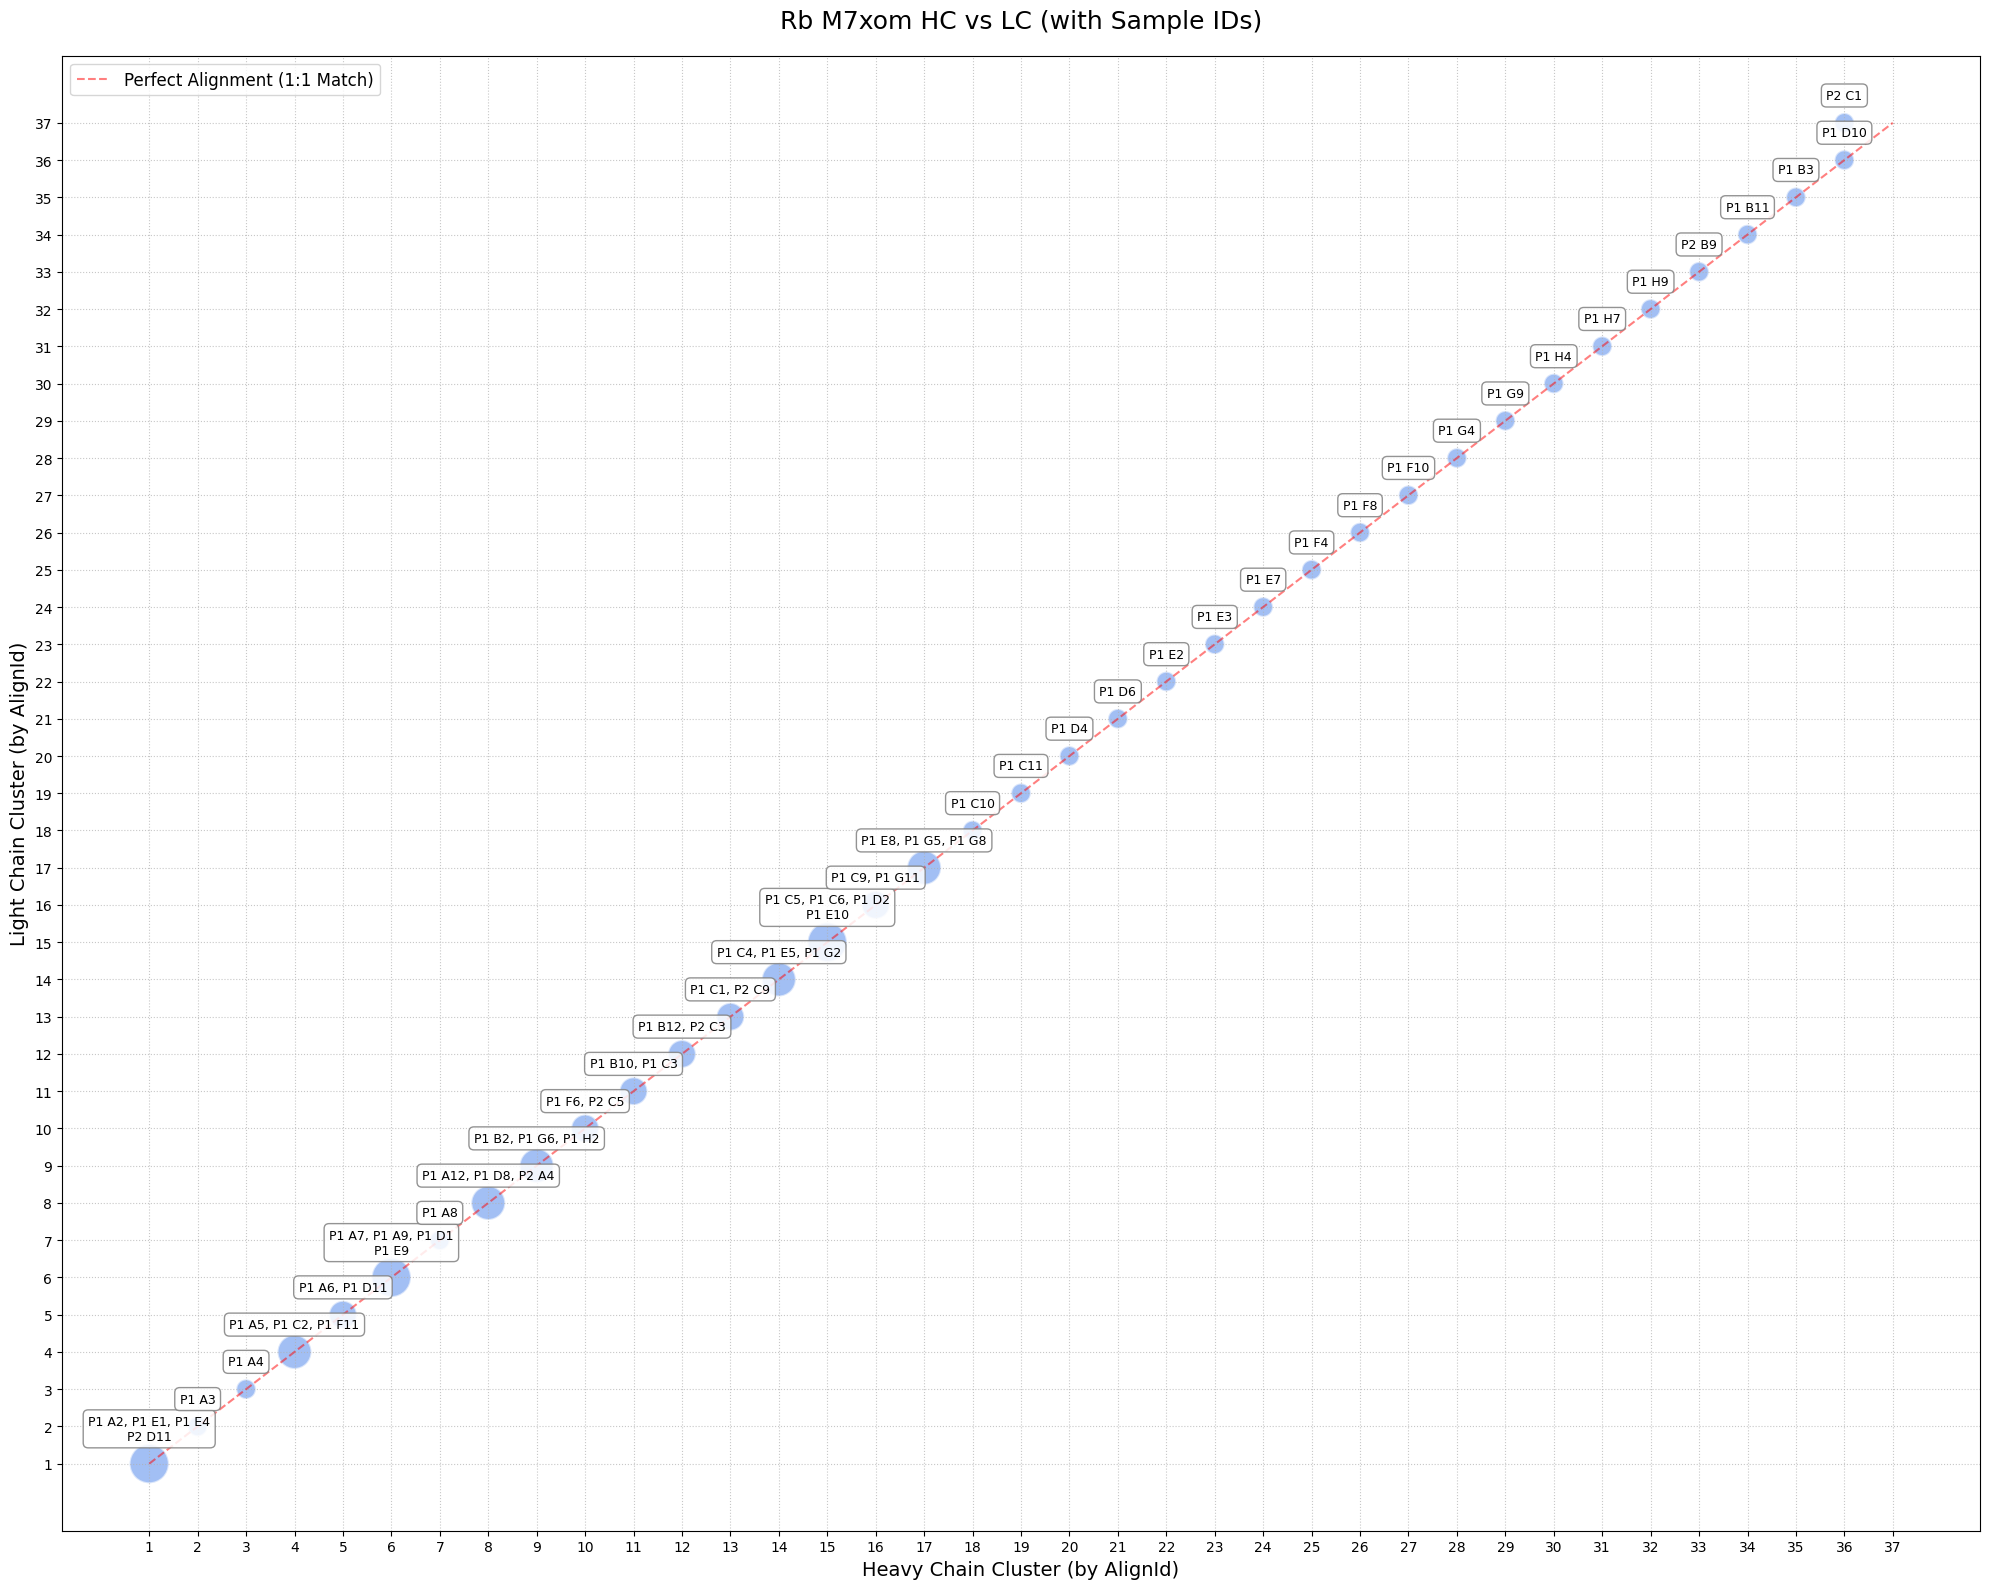

In [22]:
df = pd.read_csv('Rb7xom CSV for Cluster - Numerical (Cleaned).csv')

processed_df = df.dropna(subset=['HC_AlignID', 'LC_AlignID', 'SampleID']).copy()

def format_labels(id_list):
    ids = list(id_list)
    chunks = [", ".join(ids[i:i+3]) for i in range(0, len(ids), 3)]
    return "\n".join(chunks)

grouped = processed_df.groupby(['HC_AlignID', 'LC_AlignID'])

bubble_data = grouped.size().reset_index(name='Count')
bubble_data.rename(columns={'HC_AlignID': 'AlignId_HC', 'LC_AlignID': 'AlignId_LC'}, inplace=True)

labels_df = grouped['SampleID'].apply(format_labels).reset_index(name='Label')
labels_df.rename(columns={'HC_AlignID': 'AlignId_HC', 'LC_AlignID': 'AlignId_LC'}, inplace=True)

bubble_data = pd.merge(bubble_data, labels_df, on=['AlignId_HC', 'AlignId_LC'])

plt.figure(figsize=(20, 16))

# Plot the scatter points
plt.scatter(
    bubble_data['AlignId_HC'],
    bubble_data['AlignId_LC'],
    s=bubble_data['Count'] * 200,
    alpha=0.6,
    edgecolors="w",
    linewidth=1.5,
    color='cornflowerblue'
)

# Get all unique categories across both chains to ensure the grid is square and sorted
all_cats = sorted(list(set(bubble_data['AlignId_HC']).union(set(bubble_data['AlignId_LC']))))

# Plot a diagonal line to show where perfect matches would lie
# (Fixed: Using the categorical list instead of min/max numerical values)
plt.plot(all_cats, all_cats, color='red', linestyle='--', alpha=0.5, label='Perfect Alignment (1:1 Match)')

# Add labels to the plot
for i, row in bubble_data.iterrows():
    # Offset labels slightly upwards to prevent covering the center of the bubble
    plt.annotate(
        row['Label'],
        (row['AlignId_HC'], row['AlignId_LC']),
        xytext=(0, 15),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.85)
    )

plt.title('Rb M7xom HC vs LC (with Sample IDs)', fontsize=18, pad=20)
plt.xlabel('Heavy Chain Cluster (by AlignId)', fontsize=14)
plt.ylabel('Light Chain Cluster (by AlignId)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)

plt.xticks(all_cats)
plt.yticks(all_cats)

plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

#plt.savefig('labeled_cluster_match_plot.png', dpi=300)
print("Plot successfully generated and saved.")